# Notebook 4: Modelling & Results
**CRISP-DM Phase 4 & 5 — Modelling & Evaluation**

Trains Random Forest, XGBoost, LightGBM, Logistic Regression on proxy features.
Evaluates overall + per-region, ranks Ethiopian regions by predicted wealth,
and compares regions head-to-head.

> **Baseline accuracy**: ~40% (5-class, no leakage). Chance = 20%.
> With consumption aggregates accuracy is ~97% — but that is data leakage.

## 1. Setup

In [ ]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
import warnings; warnings.filterwarnings('ignore')

from data_cleaner import DataCleaner
from feature_enginner import FeatureEngineer
from data_preprocesor import DataPreprocessor
from modeling import WealthPredictor

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)
COLORS = ['#d32f2f','#f57c00','#fbc02d','#388e3c','#1565c0']

## 2. Load, Clean, Engineer, Split

In [ ]:
df_raw   = pd.read_csv('../data/processed/all_waves_clean.csv')
df_clean = DataCleaner().fit_transform(df_raw)
df       = FeatureEngineer().engineer_all(df_clean)

dp     = DataPreprocessor()
splits = dp.fit(df)

print(f'Train: {splits["split_sizes"]["train"]:,}  '
      f'Val: {splits["split_sizes"]["val"]:,}  '
      f'Test: {splits["split_sizes"]["test"]:,}')
print(f'Features: {splits["n_features"]}')

Train: 13,180  Val: 3,042  Test: 4,056
Features: 0


## 3. Train All Models

In [ ]:
wp = WealthPredictor()

results = wp.train_evaluate(
    splits['X_train'], splits['y_train'],
    splits['X_test'],  splits['y_test'],
)
results

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

## 4. Model Comparison Chart

NameError: name 'results' is not defined

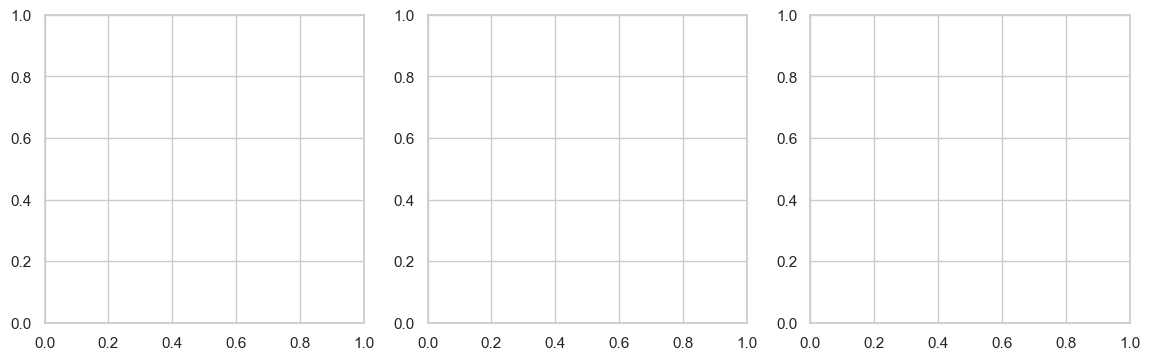

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, color, title in zip(
    axes,
    ['accuracy','weighted_f1','macro_f1'],
    ['#1976D2','#388e3c','#f57c00'],
    ['Test Accuracy','Weighted F1','Macro F1'],
):
    bars = ax.barh(results['model'], results[col], color=color,
                   edgecolor='white', alpha=0.85)
    ax.set_xlabel(title)
    ax.set_title(title)
    ax.set_xlim(0, 1)
    for bar, v in zip(bars, results[col]):
        ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=9)

plt.suptitle(f'Model Comparison — Best: {wp.best_name_}', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Classification Report

In [ ]:
wp.classification_report_df(splits['X_test'], splits['y_test'])

## 6. Confusion Matrix

In [ ]:
cm_df = wp.confusion_matrix_df(splits['X_test'], splits['y_test'])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label':'Count'})
ax.set_xlabel('Predicted Quintile')
ax.set_ylabel('True Quintile')
ax.set_title(f'Confusion Matrix — {wp.best_name_}')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Cross-Validation Results

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(results['model'], results['cv_f1_mean'],
        xerr=results['cv_f1_std'], color='#1976D2',
        edgecolor='white', alpha=0.85, capsize=5)
ax.set_xlabel('CV Weighted F1 (mean ± std)')
ax.set_title(f'{splits["split_sizes"]["train"]}-sample Stratified K-Fold CV')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig('../reports/cross_validation.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Feature Importance

In [ ]:
feat_names = splits['feature_names']
imp_df = wp.feature_importance(feat_names, top_n=20)
imp_df

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
        color='#1565c0', edgecolor='white', alpha=0.85)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title(f'Top 20 Features — {wp.best_name_}')
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Per-Region Models
One model per region trained on cons_quint from proxy features.

In [ ]:
feat_cols = splits['feature_names']
reg_df = wp.train_per_region(df, feat_cols)
reg_df

## 10. Regional Wealth Ranking

In [ ]:
ranking = wp.regional_ranking(reg_df)
ranking

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
norm_q = (ranking['mean_pred_quintile'] - ranking['mean_pred_quintile'].min())
norm_q = norm_q / (norm_q.max() or 1)
bar_colors = plt.cm.RdYlGn(norm_q.values)

bars = ax.barh(ranking['region'], ranking['mean_pred_quintile'],
               color=bar_colors, edgecolor='white')
ax.axvline(3, color='grey', linestyle='--', alpha=0.7, label='Q3 midpoint')
ax.set_xlabel('Mean Predicted Wealth Quintile')
ax.set_title('Ethiopian Regional Wealth Ranking\n(Rank 1 = Wealthiest)')

for i, (_, row) in enumerate(ranking.iterrows()):
    ax.text(0.05, i, f"#{int(row['wealth_rank'])}",
            va='center', fontsize=9, fontweight='bold', color='white')
    ax.text(row['mean_pred_quintile'] + 0.02, i,
            f"Q{row['mean_pred_quintile']:.2f}  "
            f"(Q1:{row.get('pct_q1_poorest',0):.0f}% Q5:{row.get('pct_q5_wealthiest',0):.0f}%)",
            va='center', fontsize=8)

ax.legend()
ax.set_xlim(0, 5.5)
plt.tight_layout()
plt.savefig('../reports/regional_ranking.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. Region-to-Region Comparisons

In [ ]:
# Richest vs Poorest
wp.compare_regions('ADDIS ABABA', 'AMHARA')

In [ ]:
wp.compare_regions('TIGRAY', 'OROMIA')

In [ ]:
wp.compare_regions('ADDIS ABABA', 'SOMALI')

### 11a. All pairwise wealth gaps

In [ ]:
all_pairs = wp.compare_all_pairs()
all_pairs.head(15)

In [ ]:
# Pairwise gap heatmap
regions = sorted(wp.region_models_.keys())
n = len(regions)
matrix = pd.DataFrame(np.nan, index=regions, columns=regions)
for _, row in all_pairs.iterrows():
    matrix.loc[row['region_a'], row['region_b']] = row['mean_q_a'] - row['mean_q_b']
    matrix.loc[row['region_b'], row['region_a']] = row['mean_q_b'] - row['mean_q_a']
np.fill_diagonal(matrix.values, 0)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(matrix.astype(float), annot=True, fmt='.2f', cmap='RdBu',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Mean Q (row) − Mean Q (col)'})
ax.set_title('Pairwise Regional Wealth Gap\n(positive = row region wealthier)')
plt.tight_layout()
plt.savefig('../reports/pairwise_region_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 12. Quintile Distribution by Region

In [ ]:
n_reg = len(regions)
n_cols = 4
n_rows = -(-n_reg // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3), sharey=False)

for i, region in enumerate(sorted(regions)):
    ax = axes.flat[i]
    m  = wp.region_models_[region]
    y  = m['y_pred']
    vals, cnts = np.unique(y, return_counts=True)
    ax.bar([f'Q{int(v)}' for v in vals], cnts,
           color=[COLORS[int(v)-1] for v in vals], edgecolor='white')
    ax.set_title(f"{region}\nMean Q={m['mean_pred_q']:.2f}", fontsize=9)
    ax.set_xlabel('')

for j in range(i+1, len(axes.flat)):
    axes.flat[j].set_visible(False)

plt.suptitle('Predicted Wealth Quintile Distribution by Region', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/region_quintile_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## 13. Save Models

In [ ]:
wp.save('../models')
dp.save('../models/preprocessor.pkl')
print('Models saved to ../models/')